In [7]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [3]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [5]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [9]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [12]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [14]:
x=df.iloc[:,1:3]
y=df.iloc[:,0]

In [16]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

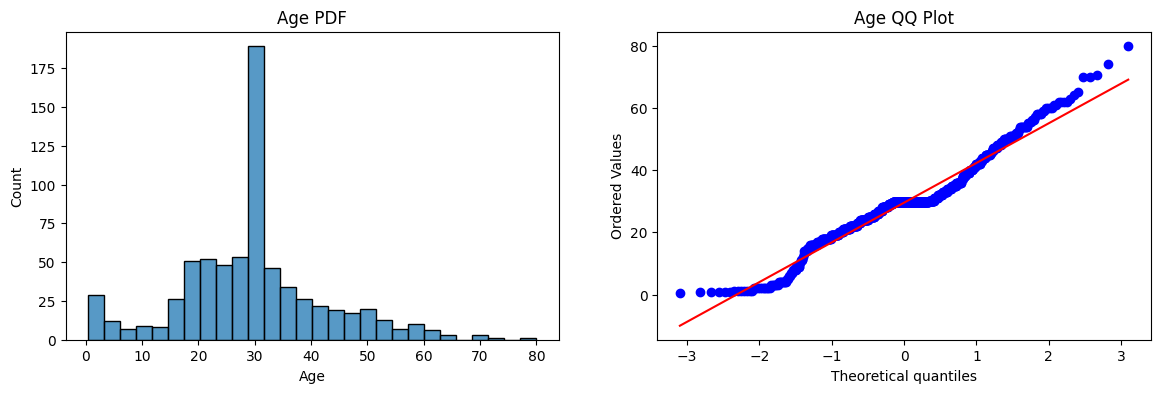

In [20]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'],dist='norm',plot=plt)
plt.title('Age QQ Plot')
plt.show()

In [22]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [25]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred=clf.predict(X_test)
y_pred1=clf2.predict(X_test)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.6927374301675978


In [26]:
trf=FunctionTransformer(func=np.log1p)

In [29]:
x_train_transformed=trf.fit_transform(X_train)
x_test_transformed=trf.transform(X_test)

In [30]:
clf=LogisticRegression()


In [31]:
clf2=DecisionTreeClassifier()

In [33]:
clf.fit(x_train_transformed,y_train)
clf2.fit(x_test_transformed,y_test)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [34]:
y_pred=clf.predict(X_test)
y_pred1=clf2.predict(X_test)

In [35]:
print ("Accuracy LR", accuracy_score(y_test,y_pred))
print("Accuracy DI",accuracy_score(y_test,y_pred))

Accuracy LR 0.7374301675977654
Accuracy DI 0.7374301675977654


In [40]:
X_transformed=trf.fit_transform(x)
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6566416978776529


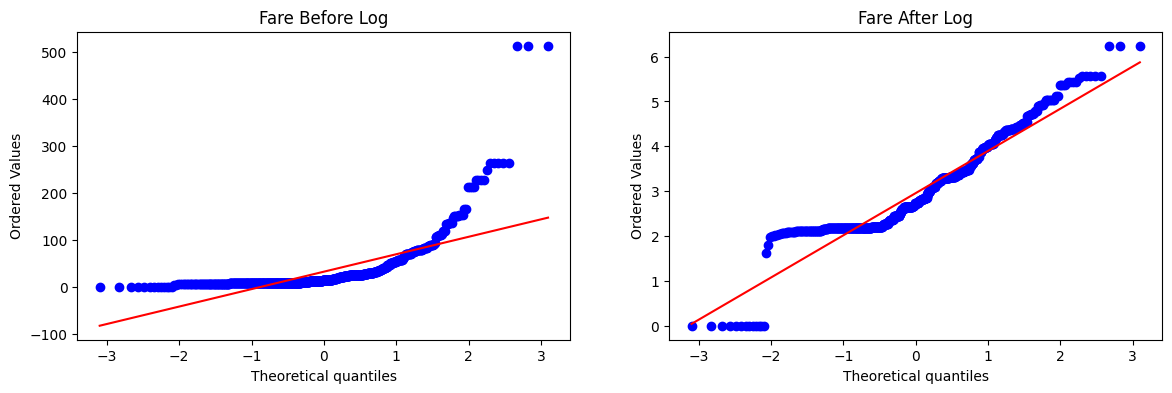

In [44]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Fare'],dist='norm',plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(x_train_transformed['Fare'],dist="norm",plot=plt)
plt.title('Fare After Log')
plt.show()

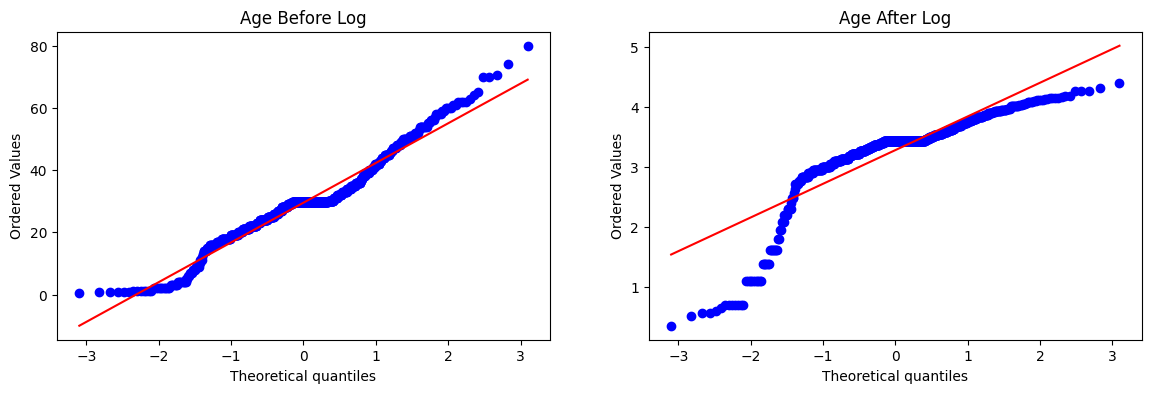

In [45]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Age'],dist='norm',plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(x_train_transformed['Age'],dist="norm",plot=plt)
plt.title('Age After Log')
plt.show()

In [48]:
trf2=ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')
X_train_transformed2=trf2.fit_transform(X_train)
X_test_transformed2=trf2.transform(X_test)

In [ ]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()
clf.fit(x_train_transformed,y_train)
clf2.fit(x_test_transformed,y_test)
y_pred=clf.predict(X_test_transformed2)
y_pred1=clf2.predict(X_test_transformed2)

In [49]:
print ("Accuracy LR", accuracy_score(y_test,y_pred))
print("Accuracy DI",accuracy_score(y_test,y_pred))

Accuracy LR 0.7374301675977654
Accuracy DI 0.7374301675977654


In [50]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()


Accuracy 0.6195131086142323


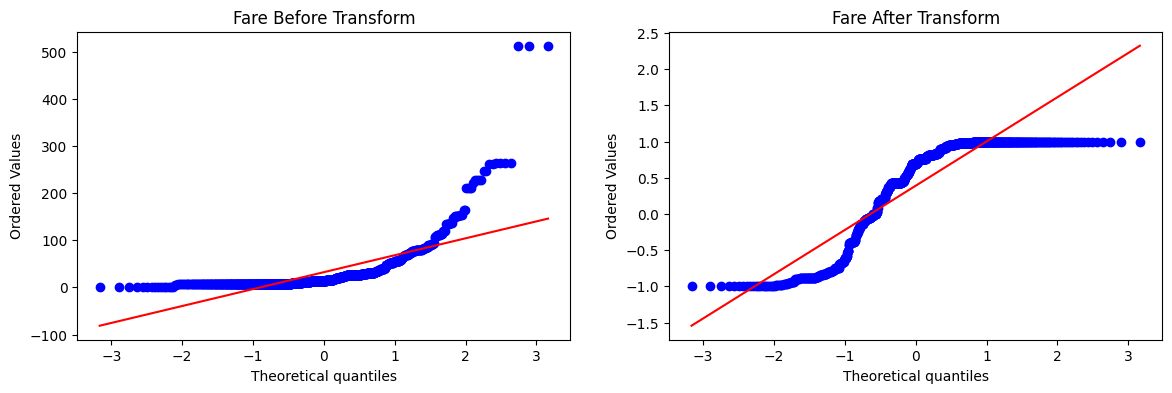

In [51]:

apply_transform(np.sin)